In [79]:
# -----------------------------------------------------------------------
# Config: reads param.in to locate data and plots directories.
# Edit PARAM_FILE if your param.in lives elsewhere.
# -----------------------------------------------------------------------
import shlex
from pathlib import Path

PARAM_FILE = Path("param.in")   # adjust if needed

_defaults = {"output_dir": "programs/data", "output_name": "dtrimp_results", "model": "1"}
_cfg = dict(_defaults)

if PARAM_FILE.exists():
    tokens = shlex.split(PARAM_FILE.read_text())
    _it = iter(tokens)
    for tok in _it:
        if tok in ("--output_dir", "--output_name", "--model"):
            _cfg[tok.lstrip("-")] = next(_it)
        # flags without value that could confuse the parser are skipped automatically
else:
    print(f"WARNING: {PARAM_FILE} not found — using defaults")

data_dir  = Path(_cfg["output_dir"])
plots_dir = data_dir / "plots"
model     = int(_cfg["model"])

print(f"model      = {model}")
print(f"data_dir   = {data_dir}")
print(f"plots_dir  = {plots_dir}")


model      = 1
data_dir   = data/Mickey1
plots_dir  = data/Mickey1/plots


In [80]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

def load_dat(filepath):
    data = np.loadtxt(filepath)
    return data[:, 0], data[:, 1], data[:, 2]  # t, Re, Im

def plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles, ylabel="G(t,0)"):
    for label, filename in dat_files.items():
        filepath = data_dir / filename
        if filepath.exists():
            t, Re, Im = load_dat(filepath)
            ax_re.plot(t, Re, color=colors[label], linestyle=linestyles[label], lw=2, label=label)
            ax_im.plot(t, Im, color=colors[label], linestyle=linestyles[label], lw=2, label=label)
        else:
            print(f"File not found: {filepath}")
    for ax, part in [(ax_re, "Re"), (ax_im, "Im")]:
        ax.set_xlabel("t", fontsize=12)
        ax.set_ylabel(f"{part} {ylabel}", fontsize=12)
        ax.set_title(f"{part} {ylabel}", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)


# Model 1

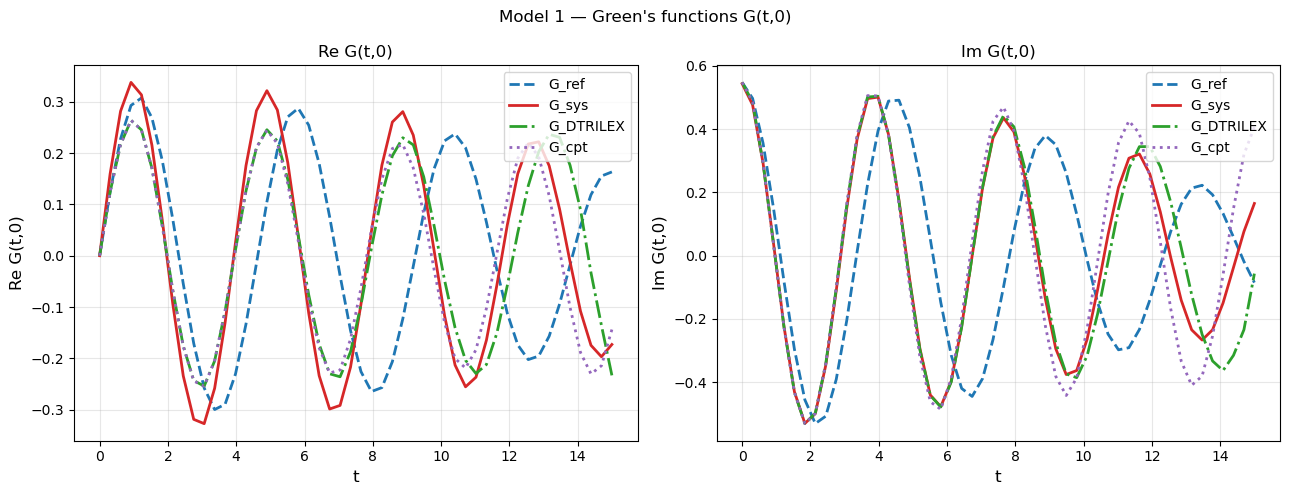

In [81]:
if model == 1:
    dat_files = {
        "G_ref":     "G_ref.dat",
        "G_sys":     "G_sys.dat",
        "G_DTRILEX": "G_Dtrilex.dat",
        "G_cpt":     "G_cpt.dat",
    }
    colors     = {"G_ref": "tab:blue", "G_sys": "tab:red", "G_DTRILEX": "tab:green", "G_cpt": "tab:purple"}
    linestyles = {"G_ref": "--",       "G_sys": "-",       "G_DTRILEX": "-.",          "G_cpt": ":"}

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 1 — Green's functions G(t,0)")
    plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles)
    plt.tight_layout()
    plots_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(plots_dir / "M1_G.png", dpi=150)
    plt.show()
else:
    print("Skipping Model 1 G plot (model != 1)")


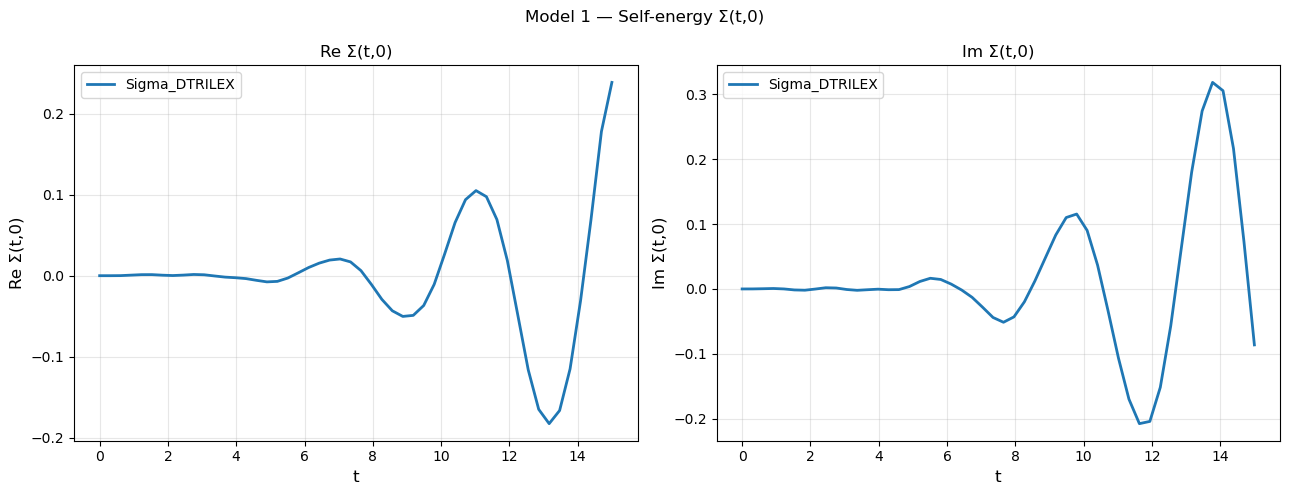

In [82]:
if model == 1:
    dat_files  = {"Sigma_DTRILEX": "Sigma_Dtrilex.dat"}
    colors     = {"Sigma_DTRILEX": "tab:blue"}
    linestyles = {"Sigma_DTRILEX": "-"}

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 1 — Self-energy Σ(t,0)")
    plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles, ylabel="Σ(t,0)")
    plt.tight_layout()
    plots_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(plots_dir / "M1_Sigma.png", dpi=150)
    plt.show()
else:
    print("Skipping Model 1 Σ plot (model != 1)")


# Model 2

## Parallel

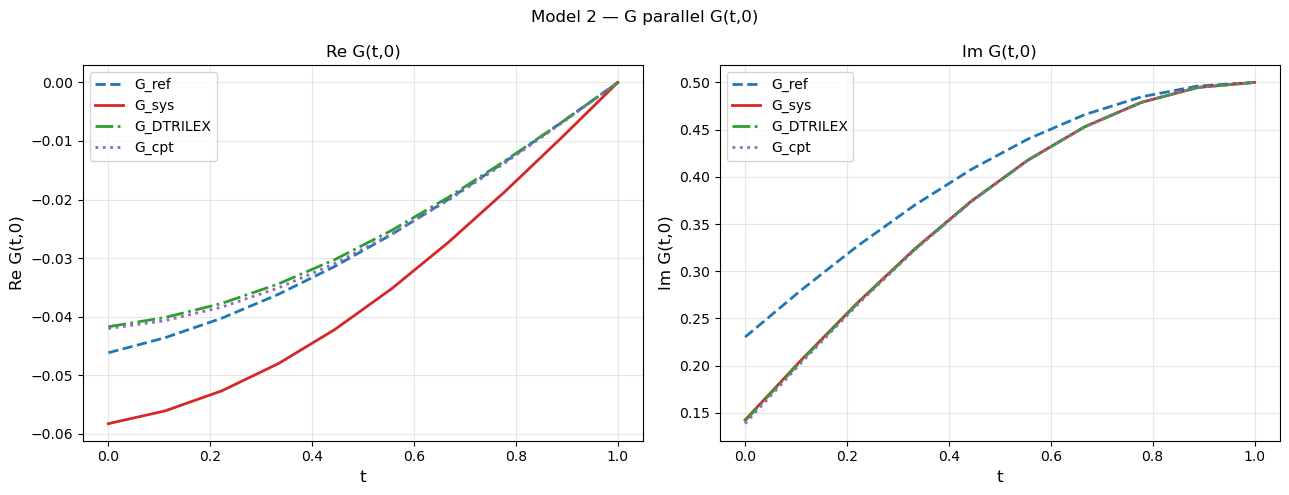

In [24]:
if model == 2:
    dat_files = {
        "G_ref":     "G_ref.dat",
        "G_sys":     "G_sys_par.dat",
        "G_DTRILEX": "G_Dtrilex_par.dat",
        "G_cpt":     "G_cpt_par.dat",
    }
    colors     = {"G_ref": "tab:blue", "G_sys": "tab:red", "G_DTRILEX": "tab:green", "G_cpt": "tab:purple"}
    linestyles = {"G_ref": "--",       "G_sys": "-",       "G_DTRILEX": "-.",          "G_cpt": ":"}

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 2 — G parallel G(t,0)")
    plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles)
    plt.tight_layout()
    plots_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(plots_dir / "M2_G_par.png", dpi=150)
    plt.show()
else:
    print("Skipping Model 2 G‖ plot (model != 2)")


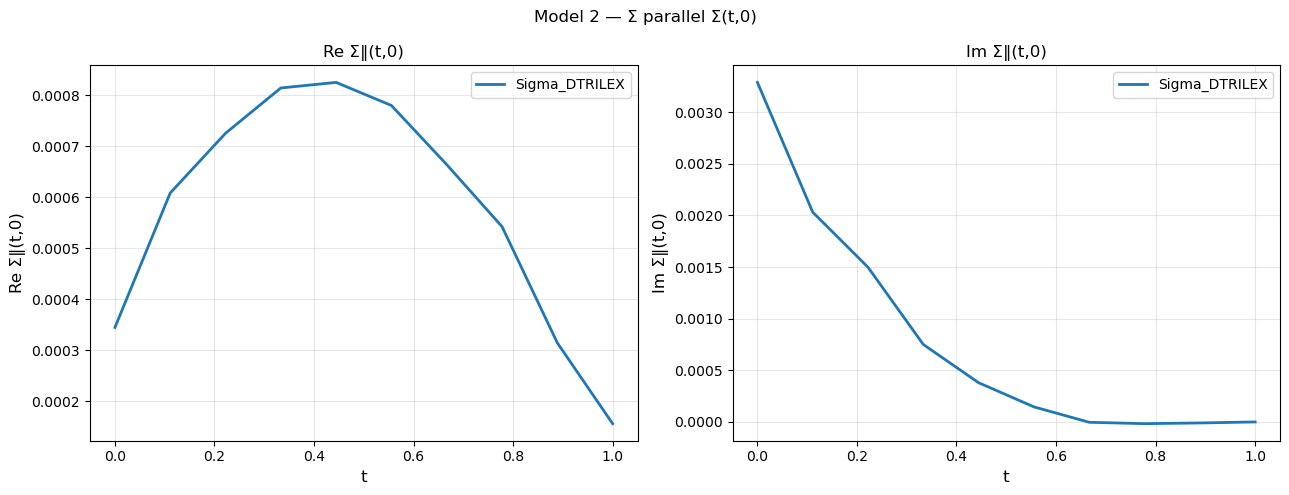

In [25]:
if model == 2:
    dat_files  = {"Sigma_DTRILEX": "Sigma_Dtrilex_par.dat"}
    colors     = {"Sigma_DTRILEX": "tab:blue"}
    linestyles = {"Sigma_DTRILEX": "-"}

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 2 — Σ parallel Σ(t,0)")
    plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles, ylabel="Σ‖(t,0)")
    plt.tight_layout()
    plots_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(plots_dir / "M2_Sigma_par.png", dpi=150)
    plt.show()
else:
    print("Skipping Model 2 Σ‖ plot (model != 2)")


## Perpendicular

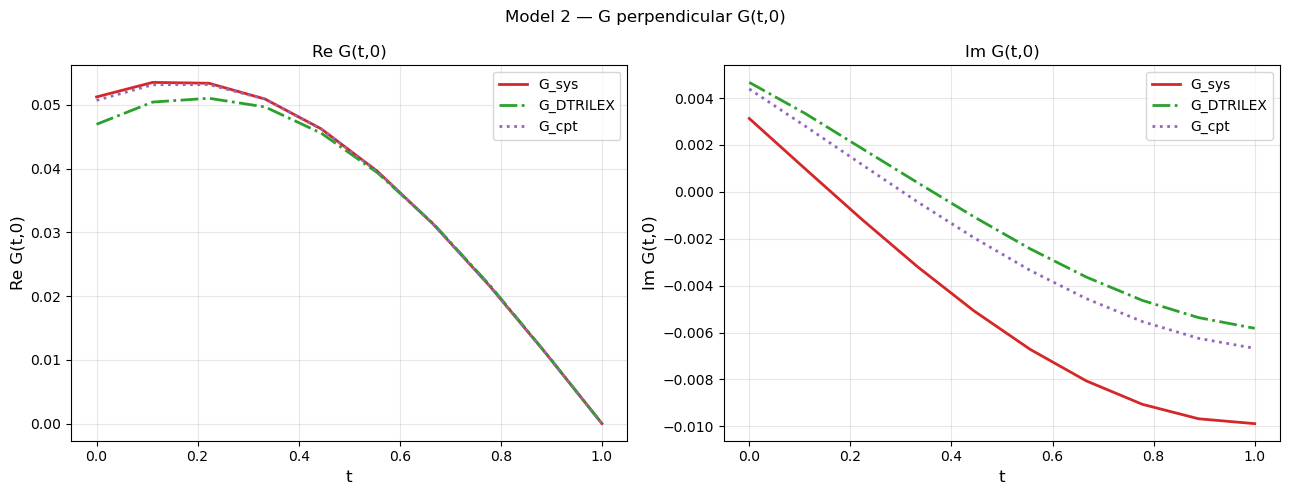

In [26]:
if model == 2:
    dat_files = {
        "G_sys":     "G_sys_perp.dat",
        "G_DTRILEX": "G_Dtrilex_perp.dat",
        "G_cpt":     "G_cpt_perp.dat",
    }
    colors     = {"G_sys": "tab:red", "G_DTRILEX": "tab:green", "G_cpt": "tab:purple"}
    linestyles = {"G_sys": "-",       "G_DTRILEX": "-.",          "G_cpt": ":"}

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 2 — G perpendicular G(t,0)")
    plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles)
    plt.tight_layout()
    plots_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(plots_dir / "M2_G_perp.png", dpi=150)
    plt.show()
else:
    print("Skipping Model 2 G⊥ plot (model != 2)")


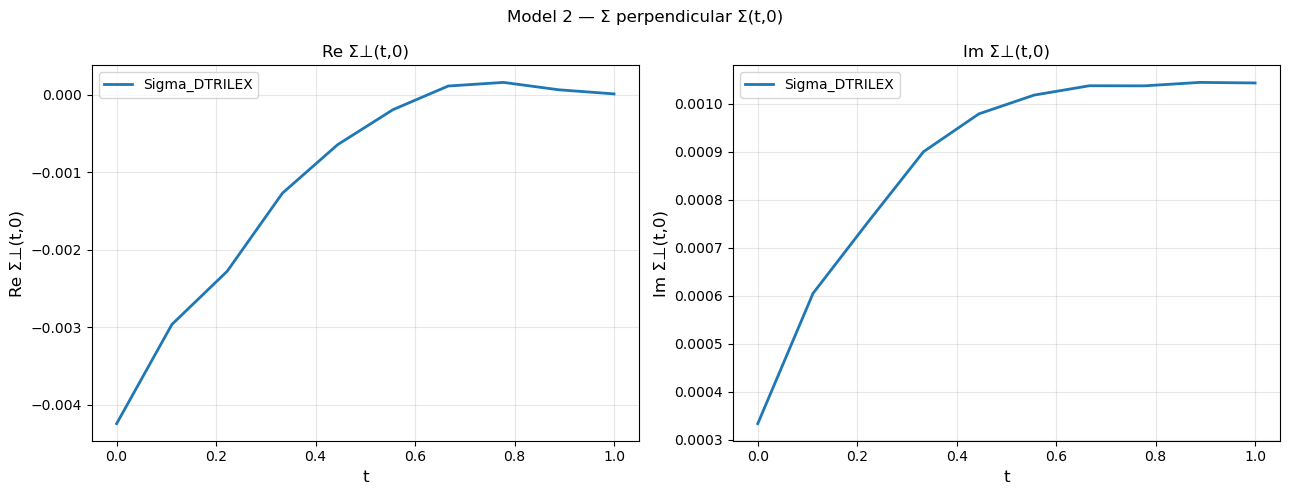

In [27]:
if model == 2:
    dat_files  = {"Sigma_DTRILEX": "Sigma_Dtrilex_perp.dat"}
    colors     = {"Sigma_DTRILEX": "tab:blue"}
    linestyles = {"Sigma_DTRILEX": "-"}

    fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model 2 — Σ perpendicular Σ(t,0)")
    plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles, ylabel="Σ⊥(t,0)")
    plt.tight_layout()
    plots_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(plots_dir / "M2_Sigma_perp.png", dpi=150)
    plt.show()
else:
    print("Skipping Model 2 Σ⊥ plot (model != 2)")
